<a href="https://colab.research.google.com/github/BaeJinYeong01/-/blob/main/Production_Scheduling_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 스케쥴링 실습 (기본)


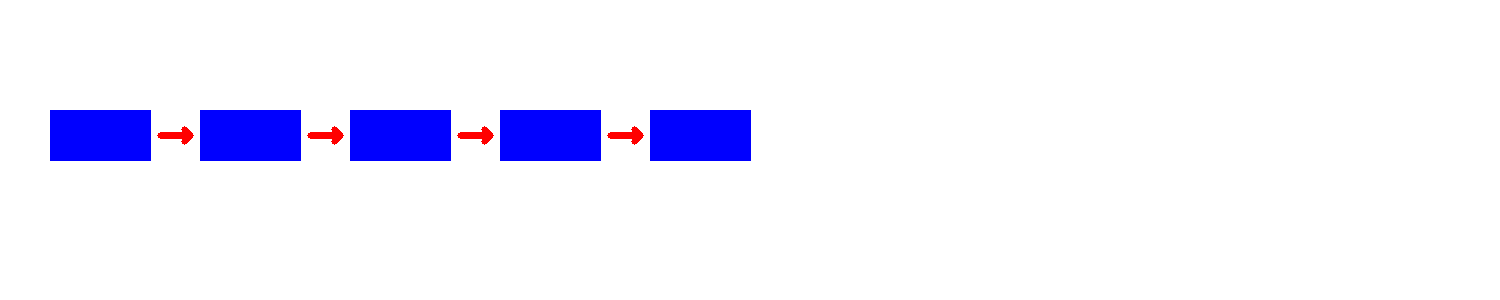

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
# Necessary import if we are working in Google Colab. Otherwise,
# if will use cv2.imshow(), this import is not required.
from google.colab.patches import cv2_imshow

img = np.zeros((300, 1500, 3), dtype="uint8")
img[:] = (255,255,255)
cv2.rectangle(img, (50,110), (150,160), (255,0,0), (-1))
cv2.arrowedLine(img, (160,135), (190,135), (0,0,255), (5), 8,0,0.3)
cv2.rectangle(img, (200,110), (300,160), (255,0,0), (-1))
cv2.arrowedLine(img, (310,135), (340,135), (0,0,255), (5), 8,0,0.3)
cv2.rectangle(img, (350,110), (450,160), (255,0,0), (-1))
cv2.arrowedLine(img, (460,135), (490,135), (0,0,255), (5), 8,0,0.3)
cv2.rectangle(img, (500,110), (600,160), (255,0,0), (-1))
cv2.arrowedLine(img, (610,135), (640,135), (0,0,255), (5), 8,0,0.3)
cv2.rectangle(img, (650,110), (750,160), (255,0,0), (-1))
cv2_imshow(img)

## 접근 방법

BOM을 보면 제품 15101008 을 만들기 위해서 25151005와 35101014, 35101015, 그리고 35101013 의 반제품이 필요하고, 해당 반제품을 만들기 위해서 소요되는 작업 시간을 계산해야 합니다. 따라서 아래와 같은 방식으로 접근해야 합니다.

1. BOM을 분석해서 필요한 반제품을 계산하는데 들어가는 시간과 반제품들을 조립해서 제품을 만드는 데 걸리는 각 공정별 평균 소요 시간을 계산합니다.

2. 각 공정별 평균 소요 시간을 바탕으로 표준공수를 구합니다.

3. 표준 공수에 작업지시서상 갯수를 곱해서 총 필요한 작업 소요시간을 구합니다.

4. 가용한 인원을 바탕으로 가용한 시간을 구한 뒤에 필요한 작업 소요시간과 비교합니다.

5. 만약 현재 가용인력이 충분하지 않다면 일용직을 추가로 고용합니다.






## 1. BOM을 분석해서 필요한 반제품을 계산하는데 들어가는 시간과 반제품들을 조립해서 제품을 만드는 데 걸리는 각 공정별 평균 소요 시간을 계산합니다.


데이터를 먼저 읽어들입니다.

In [ ]:
from google.colab import files
uploaded=files.upload()


Saving exercise_3_basic.xlsx to exercise_3_basic.xlsx


In [ ]:
import pandas as pd
import numpy as np
import io

df=pd.read_excel(io.BytesIO(uploaded['exercise_3_basic.xlsx']))

df

df.head()



,A Process,B Process,C Process,D Process,E Process
0,2.988561,2.049931,2.513857,1.007318,1.991486
1,2.899687,1.962657,2.587462,1.010602,2.149283
2,2.999185,1.958594,2.483914,1.017890,1.972110
3,3.022741,1.969699,2.491001,0.988635,1.990637
4,2.911437,2.027810,2.542645,0.996162,2.097959


In [ ]:
print(df.mean())


A Process    3.000569
B Process    1.999302
C Process    2.499597
D Process    0.999877
E Process    1.999705
dtype: float64


In [ ]:
print(df.var())


A Process    0.009985
B Process    0.003614
C Process    0.002511
D Process    0.000400
E Process    0.012201
dtype: float64


## 2. 각 공정별 평균 소요 시간을 바탕으로 표준공수를 구합니다.

각 공정별 평균 소요 시간을 바탕으로 품목코드별 표준공수를 구합니다.


---
A 공정 : 15101008

B 공정 : 25151005

C 공정 : 35101014

D 공정 : 35101015

E 공정 : 35101013

---

In [ ]:
p1 = df.mean()

print(p1)

A Process    3.000569
B Process    1.999302
C Process    2.499597
D Process    0.999877
E Process    1.999705
dtype: float64


## 3. 표준 공수에 작업지시서상 갯수를 곱해서 총 필요한 작업 소요시간을 구합니다.

앞서 구한 공정별 평균 소요시간에 작업 지시서 상의 갯수를 곱해서 총 필요한 작업 소요 시간을 산출합니다.

In [ ]:
# 필요한 작업 소요시간을 구해 보시오.

total_process_time = df.mean().sum()

order_qty = 30

required_time = total_process_time * order_qty
required_time


np.float64(314.9714901746455)

## 4. 가용한 인원을 바탕으로 가용한 시간을 구한 뒤에 필요한 작업 소요시간과 비교합니다.


정규직 인원이 35명 있고, 연장 근무를 하지 않는다는 가정 하에 하루에 한 명 당 8시간을 일할 수 있으므로 35 X 8 = 280 입니다.

In [ ]:
# 가용한 인원을 바탕으로 한 가용시간을 구해보시오.

workers = 35
work_hours = 8

available_time = workers * work_hours
available_time

280

## 5. 만약 현재 가용인력이 충분하지 않다면 일용직을 추가로 고용합니다.

가용한 시간과 필요한 작업 소요 시간을 비교해서 필요한 시간이 가용한 시간보다 크다면 몇 명의 일용직을 추가로 고용해야 할지 산출합니다. 단, 일용직은 하루에 8시간 일한다고 가정합니다. 이 경우 필요한 작업 소요시간이 가용한 시간보다 크므로, 필요한 작업 소요 시간에서 가용한 시간을 뺀 뒤에 8로 나눈 나머지를 구해서 나머지가 0이라면 몫을 구하는 // 라는 연산자를 사용하고, 0보다 크다면 // 라는 연산자를 사용해서 구한 몫에 1을 더한 수만큼 일용직을 고용합니다.

In [ ]:
if p1.sum()*30 > 35*8 :
    if (p1.sum()*30 - 35*8)%8 == 0 :
        print((p1.sum()*30 - 35*8)//8)
    else:
        print((p1.sum()*30 - 35*8)//8 + 1)

# 나머지가 0이 아닐 때 몇 명이 필요할지 계산하는 부분을 추가해 보시오.

else :
    print("유휴 인력 발생")






5.0


# 스케쥴링 실습 (심화)

## 접근 방법

이번 문제에서는 제품을 생산하는 것에서 끝나는 것이 아니라 생산된 제품을 검사하는 것까지 고려하는 문제입니다. 위의 과정에서 검사하는 데 들어가는 시간과 현재 가용한 시간을 비교해서 필요하다면 일용직을 추가로 고용합니다.

1. 앞의 문제에서 추가된 검사 공정과 관련된 소요시간을 구합니다.

2. 가용한 인원을 바탕으로 가용한 시간을 구한 뒤에 필요한 작업 소요시간과 비교합니다.

3. 만약 현재 가용인력이 충분하지 않다면 일용직을 추가로 고용합니다.


In [ ]:
from google.colab import files
uploaded=files.upload()


Saving exercise_3_advanced.xlsx to exercise_3_advanced.xlsx


In [ ]:
import pandas as pd
import numpy as np
import io

df2=pd.read_excel(io.BytesIO(uploaded['exercise_3_advanced.xlsx']))

df2

df2.head()


,A Process,B Process,C Process,D Process,E Process,Inspection
0,2.933225,2.012376,2.433966,1.005604,2.109287,0.962601
1,3.150686,1.965877,2.487798,1.000559,2.023459,0.972882
2,2.836821,2.068942,2.445502,1.004397,1.915856,0.934911
3,2.920498,2.076100,2.426640,0.977259,1.905889,1.017861
4,2.838956,1.932668,2.591215,0.993752,1.966097,0.977765


In [ ]:
print(df2.mean())

A Process     3.000794
B Process     1.999392
C Process     2.499282
D Process     1.000003
E Process     2.000165
Inspection    1.000488
dtype: float64


In [ ]:
p2 = df2.mean()

print(p2)

A Process     3.000794
B Process     1.999392
C Process     2.499282
D Process     1.000003
E Process     2.000165
Inspection    1.000488
dtype: float64


In [ ]:
if sum(p2[:5])*30 > 35*8 :
  if (sum(p2[:5])*30 - 35*8)%8 == 0 :
    print((sum(p2[:5])*30 - 35*8)//8)
  else :
    print((sum(p2[:5])*30 - 35*8)//8+1)

else:
  print("유휴 인력 발생")

if p2[5]*30 > 35*8 :
    if (p2[5]*30 - 35*8)%8 == 0 :
        print((p2[5]*30 - 35*8)//8)
    else :
        print((p2[5]*30 - 35*8)//8 + 1)
else :
    print("검사 인력 추가 필요 없음")
# 위의 구문을 참조해서 검사와 관련해서 추가 고용 여부를 판단할 수 있는 코드를 구성해 보시오.




5.0
검사 인력 추가 필요 없음


/tmp/ipykernel_156/332568915.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if p2[5]*30 > 35*8 :
